In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [ ]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna(subset=["TotalCharges"])
print("Rows after cleaning:", len(df))

Rows after cleaning: 7032


In [ ]:
print("Total Customers:", len(df))

print(
    "Churned Customers:",
    (df["Churn"] == "Yes").sum()
)

print(
    "Retained Customers:",
    (df["Churn"] == "No").sum()
)

Total Customers: 7032
Churned Customers: 1869
Retained Customers: 5163


In [ ]:
churn_rate = (
    (df["Churn"] == "Yes").mean()
) * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


In [ ]:
retention_rate = (
    (df["Churn"] == "No").mean()
) * 100

print(f"Retention Rate: {retention_rate:.2f}%")

Retention Rate: 73.42%


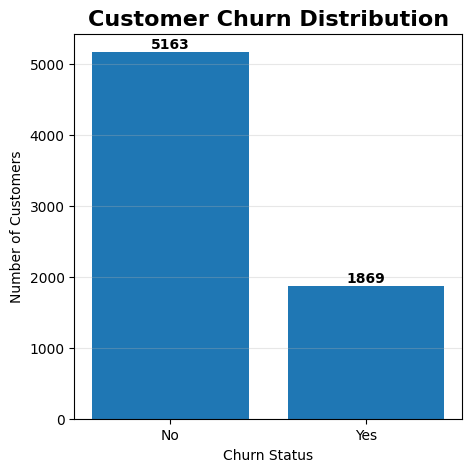

In [ ]:
import matplotlib.pyplot as plt

churn_count = df["Churn"].value_counts()

plt.figure(figsize=(5,5))

plt.bar(
    churn_count.index,
    churn_count.values
)

plt.title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_count.values):
    plt.text(
        i,
        value + 50,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

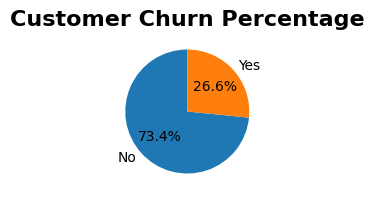

In [ ]:
plt.figure(figsize=(2,5))

plt.pie(
    churn_count.values,
    labels=churn_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Customer Churn Percentage",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [ ]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


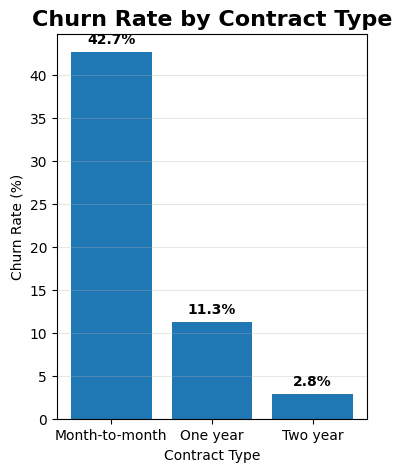

In [ ]:
plt.figure(figsize=(4,5))

bars = plt.bar(
    contract_churn.index,
    contract_churn.values
)

plt.title(
    "Churn Rate by Contract Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(
    bars,
    contract_churn.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

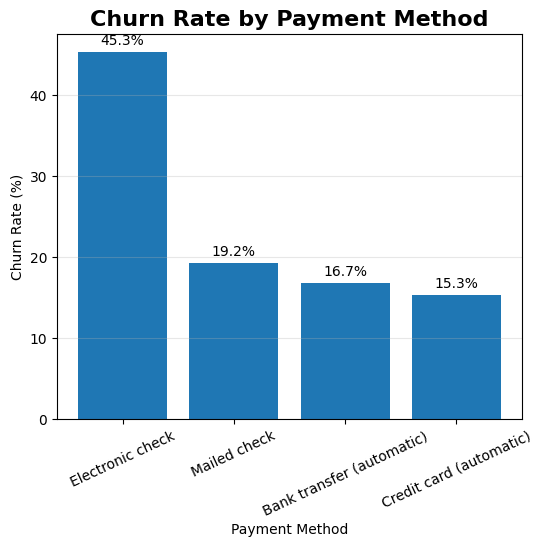

In [ ]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,5))

bars = plt.bar(
    payment_churn.index,
    payment_churn.values
)

plt.title(
    "Churn Rate by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=25)

for bar, value in zip(
    bars,
    payment_churn.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

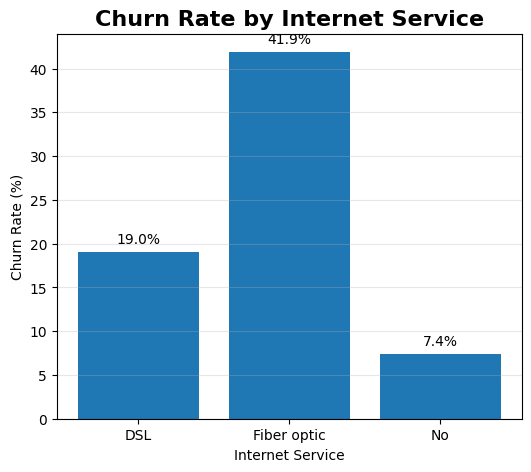

In [ ]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(6,5))

bars = plt.bar(
    internet_churn.index,
    internet_churn.values
)

plt.title(
    "Churn Rate by Internet Service",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(
    bars,
    internet_churn.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
def tenure_group(x):

    if x <= 6:
        return "0–6 Months"

    elif x <= 12:
        return "7–12 Months"

    elif x <= 24:
        return "13–24 Months"

    elif x <= 36:
        return "25–36 Months"

    elif x <= 60:
        return "37–60 Months"

    else:
        return "61–72 Months"


df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [ ]:
tenure_churn = (
    df.groupby("TenureGroup")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

order = [
    "0–6 Months",
    "7–12 Months",
    "13–24 Months",
    "25–36 Months",
    "37–60 Months",
    "61–72 Months"
]

tenure_churn = tenure_churn.reindex(order)

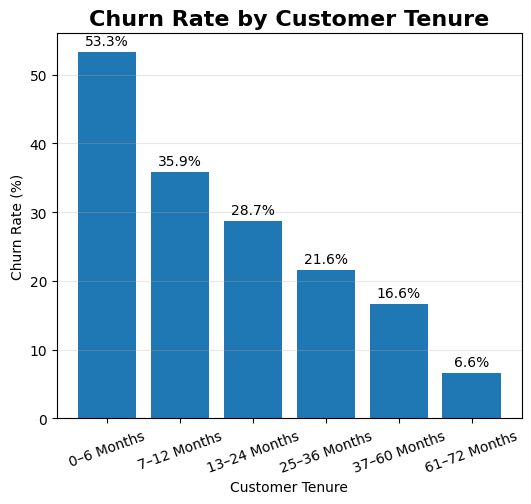

In [ ]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    tenure_churn.index,
    tenure_churn.values
)

plt.title(
    "Churn Rate by Customer Tenure",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    tenure_churn.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

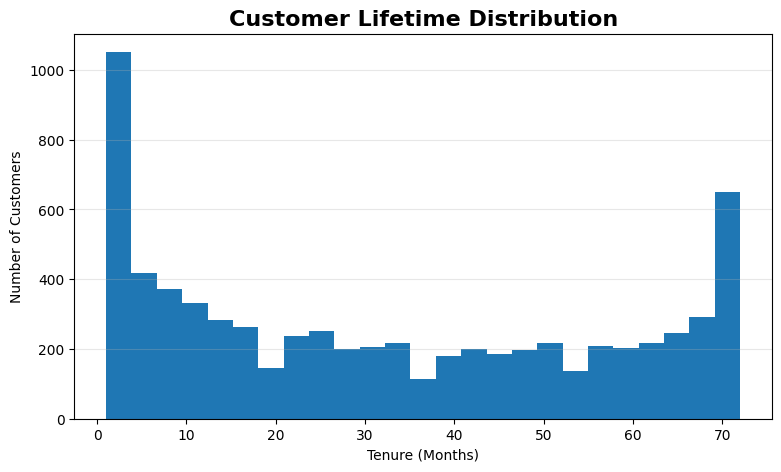

In [ ]:
plt.figure(figsize=(9,5))

plt.hist(
    df["tenure"],
    bins=25
)

plt.title(
    "Customer Lifetime Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

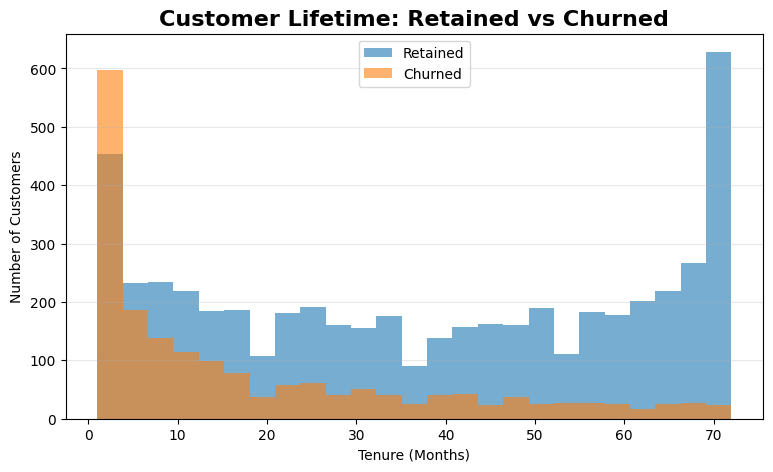

In [ ]:
plt.figure(figsize=(9,5))

plt.hist(
    df[df["Churn"] == "No"]["tenure"],
    bins=25,
    alpha=0.6,
    label="Retained"
)

plt.hist(
    df[df["Churn"] == "Yes"]["tenure"],
    bins=25,
    alpha=0.6,
    label="Churned"
)

plt.title(
    "Customer Lifetime: Retained vs Churned",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

/tmp/ipykernel_1486/2221001614.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


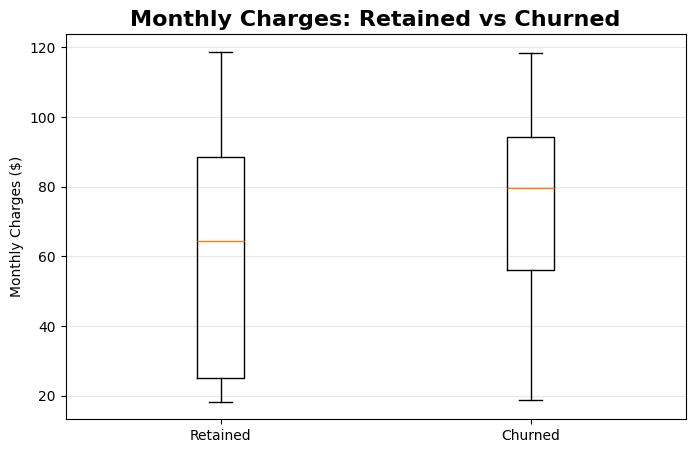

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df[df["Churn"] == "No"]["MonthlyCharges"],
        df[df["Churn"] == "Yes"]["MonthlyCharges"]
    ],
    labels=["Retained", "Churned"]
)

plt.title(
    "Monthly Charges: Retained vs Churned",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Monthly Charges ($)")

plt.grid(axis="y", alpha=0.3)

plt.show()

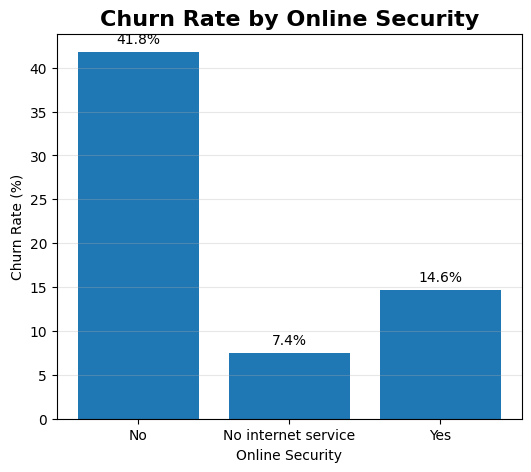

In [ ]:
security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(6,5))

bars = plt.bar(
    security_churn.index,
    security_churn.values
)

plt.title(
    "Churn Rate by Online Security",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(
    bars,
    security_churn.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

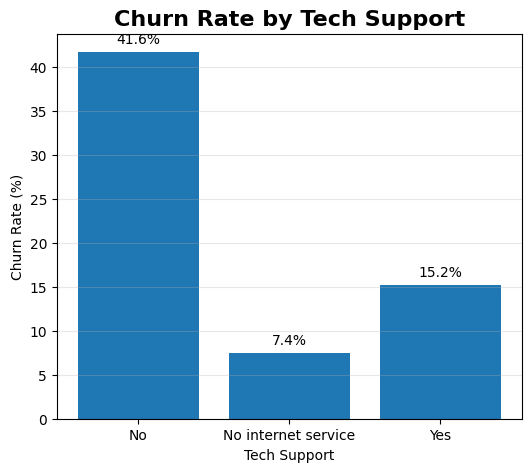

In [ ]:
support_churn = (
    df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(6,5))

bars = plt.bar(
    support_churn.index,
    support_churn.values
)

plt.title(
    "Churn Rate by Tech Support",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(
    bars,
    support_churn.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

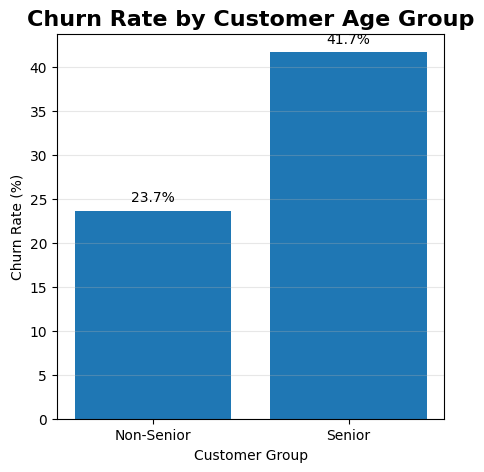

In [ ]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

senior_churn.index = [
    "Non-Senior",
    "Senior"
]

plt.figure(figsize=(5,5))

bars = plt.bar(
    senior_churn.index,
    senior_churn.values
)

plt.title(
    "Churn Rate by Customer Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(
    bars,
    senior_churn.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

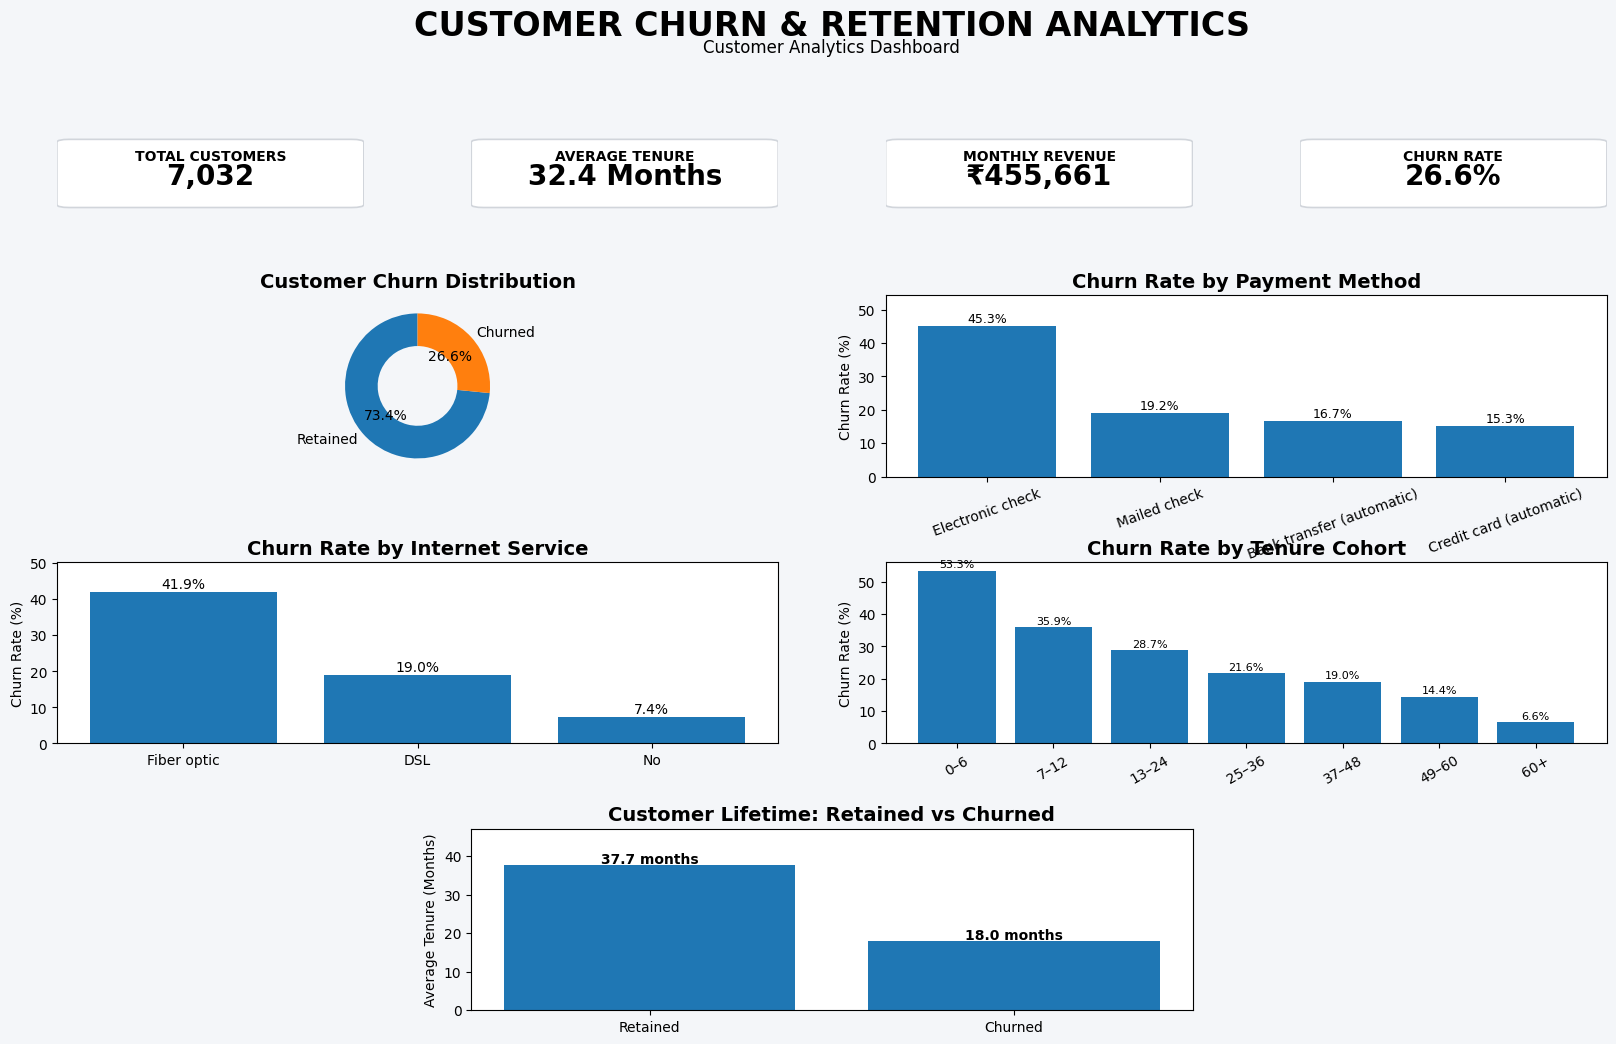

In [ ]:
# ============================================================
# PROFESSIONAL CUSTOMER CHURN DASHBOARD
# PURE PYTHON - PANDAS + MATPLOTLIB
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec

# ============================================================
# 1. DATA PREPARATION
# ============================================================

df.columns = df.columns.str.strip()

# Convert numerical columns
df["tenure"] = pd.to_numeric(
    df["tenure"],
    errors="coerce"
)

df["MonthlyCharges"] = pd.to_numeric(
    df["MonthlyCharges"],
    errors="coerce"
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove missing values from important columns
df = df.dropna(
    subset=["tenure", "MonthlyCharges", "Churn"]
)

# Create churn flag
df["Churn_Flag"] = (
    df["Churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0
    })
)

# ============================================================
# 2. KPI CALCULATIONS
# ============================================================

total_customers = len(df)

average_tenure = df["tenure"].mean()

monthly_revenue = df["MonthlyCharges"].sum()

churned_customers = df["Churn_Flag"].sum()

retained_customers = (
    total_customers - churned_customers
)

churn_rate = (
    churned_customers /
    total_customers
) * 100


# ============================================================
# 3. CHURN DISTRIBUTION
# ============================================================

churn_distribution = [
    retained_customers,
    churned_customers
]

churn_labels = [
    "Retained",
    "Churned"
]


# ============================================================
# 4. PAYMENT METHOD CHURN
# ============================================================

payment_churn = (
    df.groupby("PaymentMethod")["Churn_Flag"]
    .mean() * 100
)

payment_churn = payment_churn.sort_values(
    ascending=False
)


# ============================================================
# 5. INTERNET SERVICE CHURN
# ============================================================

internet_churn = (
    df.groupby("InternetService")["Churn_Flag"]
    .mean() * 100
)

internet_churn = internet_churn.sort_values(
    ascending=False
)


# ============================================================
# 6. TENURE COHORTS
# ============================================================

bins = [
    0,
    6,
    12,
    24,
    36,
    48,
    60,
    np.inf
]

labels = [
    "0–6",
    "7–12",
    "13–24",
    "25–36",
    "37–48",
    "49–60",
    "60+"
]

df["Tenure_Cohort"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

cohort_churn = (
    df.groupby(
        "Tenure_Cohort",
        observed=True
    )["Churn_Flag"]
    .mean() * 100
)


# ============================================================
# 7. CUSTOMER LIFETIME
# RETAINED VS CHURNED
# ============================================================

lifetime = (
    df.groupby("Churn_Flag")["tenure"]
    .mean()
)

retained_lifetime = lifetime.get(
    0,
    0
)

churned_lifetime = lifetime.get(
    1,
    0
)


# ============================================================
# 8. CREATE DASHBOARD
# ============================================================

plt.rcParams["font.family"] = "DejaVu Sans"

fig = plt.figure(
    figsize=(20, 13)
)

fig.patch.set_facecolor(
    "#F4F6F9"
)

gs = GridSpec(
    5,
    4,
    figure=fig,

    height_ratios=[
        0.7,
        1.2,
        3,
        3,
        3
    ],

    hspace=0.65,
    wspace=0.35
)


# ============================================================
# 9. DASHBOARD TITLE
# ============================================================

ax_title = fig.add_subplot(
    gs[0, :]
)

ax_title.axis("off")

ax_title.text(
    0.5,
    0.60,
    "CUSTOMER CHURN & RETENTION ANALYTICS",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax_title.text(
    0.5,
    0.10,
    "Customer Analytics Dashboard",
    ha="center",
    va="center",
    fontsize=12
)


# ============================================================
# 10. KPI CARD FUNCTION
# ============================================================

def create_kpi(
    ax,
    title,
    value
):

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.axis("off")

    card = FancyBboxPatch(
        (0.02, 0.05),
        0.96,
        0.90,

        boxstyle=
        "round,pad=0.02,rounding_size=0.04",

        linewidth=1.2,

        edgecolor="#D1D5DB",

        facecolor="white"
    )

    ax.add_patch(card)

    ax.text(
        0.5,
        0.68,
        title,

        ha="center",

        fontsize=10,

        fontweight="bold"
    )

    ax.text(
        0.5,
        0.35,
        value,

        ha="center",

        fontsize=20,

        fontweight="bold"
    )


# ============================================================
# 11. KPI CARDS
# ============================================================

create_kpi(
    fig.add_subplot(
        gs[1, 0]
    ),

    "TOTAL CUSTOMERS",

    f"{total_customers:,}"
)


create_kpi(
    fig.add_subplot(
        gs[1, 1]
    ),

    "AVERAGE TENURE",

    f"{average_tenure:.1f} Months"
)


create_kpi(
    fig.add_subplot(
        gs[1, 2]
    ),

    "MONTHLY REVENUE",

    f"₹{monthly_revenue:,.0f}"
)


create_kpi(
    fig.add_subplot(
        gs[1, 3]
    ),

    "CHURN RATE",

    f"{churn_rate:.1f}%"
)


# ============================================================
# 12. CHART 1
# CUSTOMER CHURN DISTRIBUTION
# ============================================================

ax1 = fig.add_subplot(
    gs[2, 0:2]
)

ax1.pie(
    churn_distribution,

    labels=churn_labels,

    autopct="%1.1f%%",

    startangle=90,

    wedgeprops={
        "width": 0.45
    }
)

ax1.set_title(
    "Customer Churn Distribution",

    fontsize=14,

    fontweight="bold"
)


# ============================================================
# 13. CHART 2
# CHURN BY PAYMENT METHOD
# ============================================================

ax2 = fig.add_subplot(
    gs[2, 2:4]
)

bars = ax2.bar(
    payment_churn.index,

    payment_churn.values
)

ax2.set_title(
    "Churn Rate by Payment Method",

    fontsize=14,

    fontweight="bold"
)

ax2.set_ylabel(
    "Churn Rate (%)"
)

ax2.tick_params(
    axis="x",

    rotation=20
)

for bar, value in zip(
    bars,
    payment_churn.values
):

    ax2.text(
        bar.get_x() +
        bar.get_width() / 2,

        value + 1,

        f"{value:.1f}%",

        ha="center",

        fontsize=9
    )

ax2.set_ylim(
    0,

    max(
        payment_churn.values
    ) * 1.2
)


# ============================================================
# 14. CHART 3
# CHURN BY INTERNET SERVICE
# ============================================================

ax3 = fig.add_subplot(
    gs[3, 0:2]
)

bars = ax3.bar(
    internet_churn.index,

    internet_churn.values
)

ax3.set_title(
    "Churn Rate by Internet Service",

    fontsize=14,

    fontweight="bold"
)

ax3.set_ylabel(
    "Churn Rate (%)"
)

for bar, value in zip(
    bars,
    internet_churn.values
):

    ax3.text(
        bar.get_x() +
        bar.get_width() / 2,

        value + 1,

        f"{value:.1f}%",

        ha="center"
    )

ax3.set_ylim(
    0,

    max(
        internet_churn.values
    ) * 1.2
)


# ============================================================
# 15. CHART 4
# TENURE COHORT CHURN
# ============================================================

ax4 = fig.add_subplot(
    gs[3, 2:4]
)

bars = ax4.bar(
    cohort_churn.index.astype(str),

    cohort_churn.values
)

ax4.set_title(
    "Churn Rate by Tenure Cohort",

    fontsize=14,

    fontweight="bold"
)

ax4.set_ylabel(
    "Churn Rate (%)"
)

ax4.tick_params(
    axis="x",

    rotation=30
)

for bar, value in zip(
    bars,
    cohort_churn.values
):

    ax4.text(
        bar.get_x() +
        bar.get_width() / 2,

        value + 1,

        f"{value:.1f}%",

        ha="center",

        fontsize=8
    )


# ============================================================
# 16. CHART 5
# CUSTOMER LIFETIME:
# RETAINED VS CHURNED
# ============================================================

ax5 = fig.add_subplot(
    gs[4, 1:3]
)

lifetime_labels = [
    "Retained",
    "Churned"
]

lifetime_values = [
    retained_lifetime,
    churned_lifetime
]

bars = ax5.bar(
    lifetime_labels,

    lifetime_values
)

ax5.set_title(
    "Customer Lifetime: Retained vs Churned",

    fontsize=14,

    fontweight="bold"
)

ax5.set_ylabel(
    "Average Tenure (Months)"
)

for bar, value in zip(
    bars,
    lifetime_values
):

    ax5.text(
        bar.get_x() +
        bar.get_width() / 2,

        value + 0.5,

        f"{value:.1f} months",

        ha="center",

        fontweight="bold"
    )

ax5.set_ylim(
    0,

    max(lifetime_values) * 1.25
)


# ============================================================
# 17. FINAL DASHBOARD
# ============================================================

plt.show()